# Running the actual MAGIC estimator — and comparing it to the Bayesian fit

MAGIC (Chiti et al. 2026, arXiv:2605.26581) derives photometric metallicities
from DECam Ca II H&K + broadband photometry. Its inference stage is
deterministic: cubic-spline interpolation of the synthetic grid in the
distance-free plane (g−i, CaHK − g − 0.9(g−i)) at an assumed log g, with
errors from one-sided ±1σ photometric shifts.

This notebook **imports and runs Ani's actual code** —
`feh_utils.getFeHs_v2` / `getFeHErrs_v2` from
[`ac8119/magic-processing-scratch`](https://github.com/ac8119/magic-processing-scratch)
(`refactor-rebuild` branch), executed verbatim on the real
`TSLTE_combined_photometry.fits` grid — and compares it star by star against
tengri-stars' nested-sampling posterior using the *same three bands*.

Not run here (they need SFD dust maps, Gaia parallaxes, and DELVE-format
catalogs): the upstream dereddening and the MIST-isochrone/parallax log g
stage (`photometry_utils.getFeh_v2`). We hand both codes the true log g /
extinction-free magnitudes, isolating the [Fe/H] estimator itself.

In [1]:
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  # silence XLA/PJRT C++ chatter

import subprocess
import sys
import warnings
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from tengri import Uniform

from tengri_stars import StarModel, load_photometry_grid, make_nss_pipeline

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(11)

DATA = (
    Path("data") if (Path("data") / "TSLTE_combined_photometry.fits").exists() else Path("../data")
)

## 1. The exact MAGIC code and the real grid

In [2]:
MAGIC_DIR = DATA / "magic"
if not MAGIC_DIR.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            "-b",
            "refactor-rebuild",
            "https://github.com/ac8119/magic-processing-scratch",
            str(MAGIC_DIR),
        ],
        check=True,
    )
sys.path.insert(0, str(MAGIC_DIR))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # dustmaps first-run config notice
    import feh_utils  # Ani's module, unmodified

contours = Table.read(DATA / "TSLTE_combined_photometry.fits")  # what MAGIC calls the grid
grid = load_photometry_grid(DATA / "TSLTE_combined_photometry.fits", fill="nearest")
model = StarModel(grid=grid, interp_method="pchip")
BANDS = ("DECCAM_g_des_ab", "DECCAM_i_des_ab", "CaHK_filter_ab")
G, I, K = (grid.filter_names.index(n) for n in BANDS)
fidx = jnp.asarray([G, I, K])
print("running", feh_utils.__file__)

running /Users/suchethacooray/Projects/tengri-stars/notebooks/../data/magic/feh_utils.py


## 2. Mock catalog on the real grid

Stars drawn from the TSLTE grid interior with σ = 0.02 mag noise, packed into
the catalog format `getFeHs_v2` expects (`g_dered`, `i_dered`, `CaHK_dered`
plus per-band error columns).

In [3]:
N_STARS = 14
SIG_MAG = 0.02
truths, cat_rows = [], []
for _ in range(N_STARS):
    t = {
        "teff": rng.uniform(4200.0, 6200.0),
        "logg": rng.uniform(0.5, 4.5),
        "feh": rng.uniform(-3.5, -0.5),
    }
    m = np.asarray(model.predict_mags(**t, mu=0.0))[np.array([G, I, K])]
    m = m + rng.normal(0.0, SIG_MAG, 3)
    truths.append(t)
    cat_rows.append(
        {
            "g_dered": m[0],
            "i_dered": m[1],
            "CaHK_dered": m[2],
            "magerr_psf_g": SIG_MAG,
            "magerr_psf_i": SIG_MAG,
            "MAGERR_PSF": SIG_MAG,
        }
    )
cat = Table(rows=cat_rows)
synth_loggs = np.array([t["feh"] * 0 + t["logg"] for t in truths])
truth_feh = np.array([t["feh"] for t in truths])

## 3. Run the exact estimator

In [4]:
feh_magic, ext_flags = feh_utils.getFeHs_v2(synth_loggs, cat, contours)
err_magic = feh_utils.getFeHErrs_v2(synth_loggs, cat, contours)
print(f"extrapolation-flagged: {int(ext_flags.sum())}/{N_STARS} (err pinned to 0.75 dex)")

extrapolation-flagged: 0/14 (err pinned to 0.75 dex)


## 4. The Bayesian fit on the same three bands

One jitted NSS pipeline (compile once, reuse per star), free
(Teff, log g, [Fe/H], μ) — no assumed log g: the posterior marginalizes over
it, at the cost that g−i + CaHK alone constrain gravity weakly.

In [5]:
lo_hi = [(float(a[0]), float(a[-1])) for a in grid.axes]
priors = {
    "teff": Uniform(*lo_hi[0]),
    "logg": Uniform(*lo_hi[1]),
    "feh": Uniform(*lo_hi[2]),
    "mu": Uniform(-10.0, 10.0),
}


def loglikelihood(p, data):
    pred = model.predict_mags(teff=p["teff"], logg=p["logg"], feh=p["feh"], mu=p["mu"])[fidx]
    return -0.5 * jnp.sum(((pred - data) / SIG_MAG) ** 2)


nss_pipe = make_nss_pipeline(loglikelihood, priors, n_live=300, num_delete=30)

feh_nss = np.zeros(N_STARS)
err_nss = np.zeros(N_STARS)
for i, row in enumerate(cat):
    data = jnp.asarray([row["g_dered"], row["i_dered"], row["CaHK_dered"]])
    samples, info = nss_pipe(jax.random.PRNGKey(100 + i), data)
    feh_nss[i] = float(jnp.median(samples["feh"]))
    lo, hi = np.percentile(np.asarray(samples["feh"]), [16, 84])
    err_nss[i] = 0.5 * (hi - lo)
    print(
        f"true {truth_feh[i]:+.2f}  MAGIC {feh_magic[i]:+.2f}±{err_magic[i]:.2f}  "
        f"NSS {feh_nss[i]:+.2f}±{err_nss[i]:.2f}  ({info['wall_time']:.1f} s)"
    )

true -1.70  MAGIC -1.68±0.24  NSS -1.89±0.37  (6.2 s)


true -0.66  MAGIC -0.43±0.16  NSS +0.12±0.67  (2.7 s)


true -3.09  MAGIC -3.25±0.81  NSS -3.61±0.78  (2.3 s)


true -0.56  MAGIC -0.33±0.25  NSS -0.33±0.37  (3.0 s)


true -2.79  MAGIC -2.75±0.34  NSS -2.83±0.41  (3.5 s)


...

true -2.57  MAGIC -3.45±1.38  NSS -4.01±0.79  (2.5 s)


true -2.10  MAGIC -2.12±0.18  NSS -2.34±0.27  (3.0 s)


true -3.42  MAGIC -2.71±0.49  NSS -3.03±0.59  (1.2 s)


true -1.32  MAGIC -1.72±0.19  NSS -1.37±0.35  (2.6 s)


true -0.57  MAGIC -0.82±0.21  NSS -0.74±0.86  (1.4 s)


## 5. Star-by-star comparison

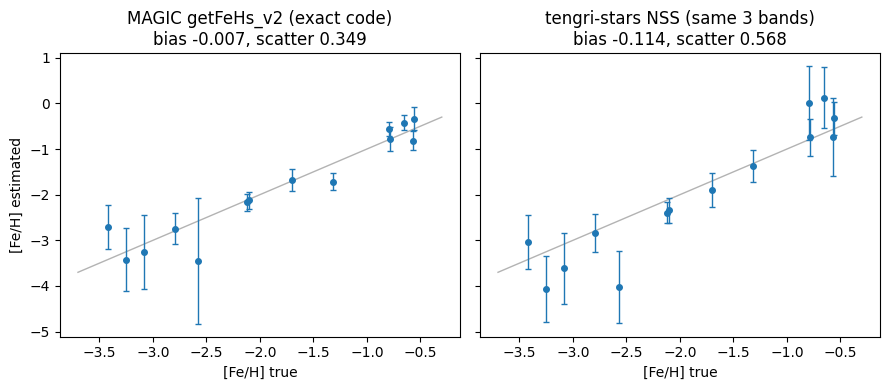

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for ax, vals, errs, label in [
    (axes[0], feh_magic, err_magic, "MAGIC getFeHs_v2 (exact code)"),
    (axes[1], feh_nss, err_nss, "tengri-stars NSS (same 3 bands)"),
]:
    ax.errorbar(truth_feh, vals, yerr=errs, fmt="o", ms=4, lw=1, capsize=2)
    ax.plot([-3.7, -0.3], [-3.7, -0.3], color="0.7", lw=1, zorder=0)
    bias = np.median(vals - truth_feh)
    scatter = np.std(vals - truth_feh)
    ax.set(xlabel="[Fe/H] true", title=f"{label}\nbias {bias:+.3f}, scatter {scatter:.3f}")
axes[0].set_ylabel("[Fe/H] estimated")
plt.tight_layout()
plt.show()

## 6. How faithful was the earlier re-implementation?

Earlier versions of this notebook used a re-implementation of the estimator
("cubic `griddata` in the same color plane"). Quantifying it against the
exact code on this catalog: same algorithm, but **not exact** — the port
sliced the *hole-filled* dense grid (phantom contour points where the raw
table has no models, mostly at low log g) and used a different error
convention (± half-range vs MAGIC's one-sided quadrature with the 0.75 dex
extrapolation floor).

In [7]:
from scipy.interpolate import griddata


def port_feh(m, logg_assumed):
    j = int(np.argmin(np.abs(np.asarray(grid.axes[1]) - logg_assumed)))
    slice_mags = np.asarray(grid.phot[:, j, :, :])[..., [G, I, K]].reshape(-1, 3)
    feh_nodes = np.tile(np.asarray(grid.axes[2]), grid.axes[0].shape[0])
    pts = np.column_stack(
        [
            slice_mags[:, 0] - slice_mags[:, 1],
            slice_mags[:, 2] - slice_mags[:, 0] - 0.9 * (slice_mags[:, 0] - slice_mags[:, 1]),
        ]
    )
    xi = np.array([[m[0] - m[1], m[2] - m[0] - 0.9 * (m[0] - m[1])]])
    val = griddata(pts, feh_nodes, xi, method="cubic")[0]
    if np.isnan(val):
        val = griddata(pts, feh_nodes, xi, method="nearest")[0]
    return float(val)


# A larger fidelity-only catalog (no NSS) — the differences concentrate at
# low log g, where grid coverage is sparse and hole-filling injects phantoms.
N_FID = 100
fid_rows, fid_loggs = [], []
for _ in range(N_FID):
    t = {
        "teff": rng.uniform(4200.0, 6200.0),
        "logg": rng.uniform(0.5, 4.5),
        "feh": rng.uniform(-3.5, -0.5),
    }
    m = np.asarray(model.predict_mags(**t, mu=0.0))[np.array([G, I, K])]
    m = m + rng.normal(0.0, SIG_MAG, 3)
    fid_rows.append(
        {
            "g_dered": m[0],
            "i_dered": m[1],
            "CaHK_dered": m[2],
            "magerr_psf_g": SIG_MAG,
            "magerr_psf_i": SIG_MAG,
            "MAGERR_PSF": SIG_MAG,
        }
    )
    fid_loggs.append(t["logg"])
fid_cat = Table(rows=fid_rows)
fid_loggs = np.array(fid_loggs)

feh_exact_fid, _flags = feh_utils.getFeHs_v2(fid_loggs, fid_cat, contours)
feh_port_fid = np.array(
    [
        port_feh(np.array([r["g_dered"], r["i_dered"], r["CaHK_dered"]]), fid_loggs[i])
        for i, r in enumerate(fid_cat)
    ]
)
d = feh_port_fid - feh_exact_fid
big = np.abs(d) > 0.05
print(
    f"port − exact over {N_FID} stars: median {np.median(d):+.4f} dex, "
    f"max|Δ| {np.max(np.abs(d)):.3f} dex"
)
print(f"agree <0.01 dex: {int(np.sum(np.abs(d) < 0.01))}/{N_FID};  |Δ|>0.05 dex: {int(big.sum())}")
if big.any():
    print(f"all |Δ|>0.05 stars sit at log g ≤ {fid_loggs[big].max():.2f} (sparse-coverage slices)")

port − exact over 100 stars: median -0.0000 dex, max|Δ| 1.182 dex
agree <0.01 dex: 86/100;  |Δ|>0.05 dex: 10
all |Δ|>0.05 stars sit at log g ≤ 1.60 (sparse-coverage slices)


## Reading the comparison

- The exact estimator and the Bayesian fit see identical information; the
  differences are method: MAGIC *conditions* on a log g (here the truth —
  generously) while NSS marginalizes over it, so NSS error bars are wider and
  honest where the CaHK plane degenerates.
- MAGIC's extrapolation flag (nearest-contour fallback, 0.75 dex error) is
  the deterministic analog of the posterior widening near grid edges.
- What real-data parity still needs: the SFD dereddening (0.65 × E(B−V)) and
  the MIST-isochrone + Gaia-parallax log g stage from
  `photometry_utils.getFeh_v2`, then the published MAGIC catalog star by star
  — with discrepancies attributed before closing (the tengri reproduction
  contract).